In [18]:
#07-May-26, Noor Natour
#Import computational functions used in the analysis.
from computational_routines import *

In [19]:
#Load feature probabilities and observed neuron counts from csv files.

df=pd.read_csv("observed_neurons.csv")
df_obs=pd.read_csv('observed_counts.csv')
feature_probs={row["feature"]: row["count"]/row["total"] for _, row in df.iterrows()}
n_neurons_all=df["total"].iloc[0]

In [28]:
#07-May-26
#Calculate the probability and expected number of neurons encoding exactly k features.
#Calls: probability_k_features()
for k in range (0, len(feature_probs)+1): #for k in range 0-5
  p_k, expected=probability_k_features(k, feature_probs, n_neurons_all)


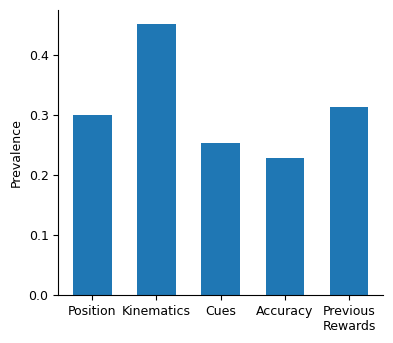

In [21]:
#09-May-26
#plot feature prevalence (Fig. 1a)

feature_names=[name.title().replace(" ", "\n") for name in df["feature"]]
prevalence=(df["count"]/df['total']).tolist()
plt.figure(figsize=(4, 3.5))
plt.rcParams.update({'font.size':9,'font.family': 'DejaVu Sans'})
plt.bar(feature_names, prevalence, width=0.6)
plt.ylabel("Prevalence")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("feature_prevalence.tiff", dpi=600, bbox_inches='tight')
plt.show()

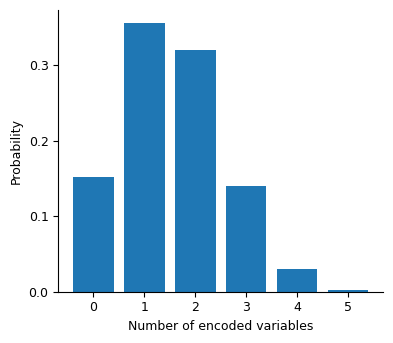

In [22]:
#09-May-26
#plot expected probability distribution (Fig. 1b)

k_probability_values=[]
probabilities=[]

for k in range(0, len(feature_probs)+1):
    p_k, expected = probability_k_features(k, feature_probs, n_neurons=303)

    k_probability_values.append(k)
    probabilities.append(p_k)

plt.figure(figsize=(4,3.5))

plt.bar(k_probability_values, probabilities)
plt.rcParams.update({'font.size': 9, 'font.family': 'DejaVu Sans'})
plt.xlabel("Number of encoded variables")
plt.ylabel("Probability")
plt.xticks(k_probability_values)
plt.yticks(np.arange(0, 0.37, 0.1))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("num_encoded_var.tiff", dpi=600, bbox_inches='tight')
plt.show()

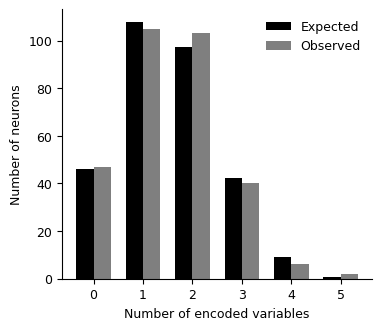

In [23]:
#07-May-26
#plot observed and expected distribution for all neurons (Fig. 2a)
k_values=list(observed_counts_all.keys())
observed_all_neurons=list(observed_counts_all.values())
expected_all_neurons=[]
for k in k_values:
  p, expected=probability_k_features(k, feature_probs, n_neurons=n_neurons_all)
  expected_all_neurons.append(expected)

x=np.arange(len(k_values))
width=0.35
plt.rcParams.update({'font.size': 9,'font.family': 'DejaVu Sans'})
plt.figure(figsize=(4, 3.5))
plt.bar(x-width/2, expected_all_neurons, width, color='k', label="Expected")
plt.bar(x+width/2, observed_all_neurons, width, color='tab:gray', label="Observed")
plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(x, k_values)
plt.legend(frameon=False)
plt.savefig("all_neurons_Ex_Ob.tiff", dpi=600, bbox_inches='tight')
plt.show()


In [24]:
#07-May-26
#Compare observed and expected distributions for all neuron (table 2b)
#Calculate the observed and expected number of neurons encoding 0–5 variables for the full cue-period neuron population.
#Calculate binomial right-tail probabilities, the geometric mean of the p-values, and a two-sample Kolmogorov-Smirnov test.
#Calls: probability_k_features(), binom_right_tail(), enumerate_discrete()
observed_counts_all=dict(zip(df_obs["k"], df_obs["all_neurons"]))
observed_values_all=[]
expected_values_all=[]
p_values_all=[]

print(f"{'k':<3} {'observed':<10} {'expected':<10} {'p(x>=obs)'}")

for k in observed_counts_all:
    p, expected=probability_k_features(k, feature_probs, n_neurons=n_neurons_all)
    observed=observed_counts_all[k]
    tail_prob = binom_right_tail(n_neurons_all, observed, p)

    observed_values_all.append(observed)
    expected_values_all.append(expected)
    p_values_all.append(tail_prob)

    print(f"{k:<3} {observed:<10} {expected:<10.2f} {tail_prob:<12.4f}")

#10-May-26
#Calculate the Kolmogorov-Smirnov test
ks_statistic_all, ks_p_value_all=ks_discrete_test(observed_counts_all.keys(), observed_counts_all.values(), expected_values_all)

#15-May-26
#Calculate the geometric mean
geo_mean_all = gmean(p_values_all)

print(f"\nGeometric mean: {geo_mean_all:.4f}")

print("\nTwo-sample Kolmogorov-Smirnov test:")
print(f"KS statistic = {ks_statistic_all:.4f}")
print(f"p-value = {ks_p_value_all:.4f}")

k   observed   expected   p(x>=obs)
0   47         45.93      0.4561      
1   105        107.78     0.6513      
2   103        97.15      0.2538      
3   40         42.39      0.6785      
4   6          9.00       0.8880      
5   2          0.75       0.1720      

Geometric mean: 0.4455

Two-sample Kolmogorov-Smirnov test:
KS statistic = 0.0132
p-value = 1.0000


In [29]:
#07-May-26
#Calculate expected distribution for reward-responsive neurons encoding exactly k features under the independent encoding model.
#Calls: probability_k_features()
n_neurons_reward=df_obs["reward_response"].sum()
for k in range (len(feature_probs)+1):
  p_k, expected=probability_k_features(k, feature_probs, n_neurons=n_neurons_reward)


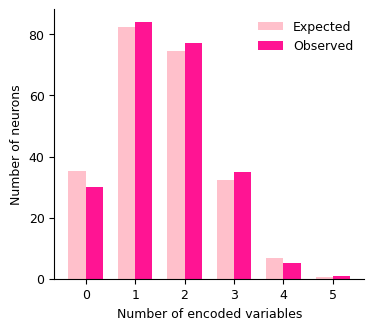

In [26]:
#07-May-26
#Plot observed and expected distribution for reward-responsive neurons (Fig. 3a)

observed_reward_response=list(observed_counts_reward.values())
expected_reward_response=[]
for k in k_values:
  p, expected=probability_k_features(k, feature_probs, n_neurons=n_neurons_reward)
  expected_reward_response.append(expected)

plt.rcParams.update({'font.size':9,'font.family': 'DejaVu Sans'})
plt.figure(figsize=(4,3.5))
plt.bar(x-width/2, expected_reward_response, width, color='pink', label="Expected")
plt.bar(x+width/2, observed_reward_response, width, color='deeppink', label="Observed")
plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
plt.xticks(x, k_values)
plt.yticks(np.arange(0, max(observed_reward_response), 20))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(frameon=False)
plt.savefig("reward_responsive_Ex_Ob.tiff", dpi=600, bbox_inches='tight')
plt.show()

In [27]:
#07-May-26
#Compare observed and expected distributions for reward-responsive neurons (table 3b)
#Calculate the observed and expected number of reward-responsive neurons encoding 0–5 variables.
#Calculate binomial right-tail probabilities, the geometric mean of the p-values, and a two-sample Kolmogorov-Smirnov test.
#Calls: probability_k_features(), binom_right_tail(), enumerate_discrete()
observed_counts_reward=dict(zip(df_obs['k'], df_obs['reward_response']))
n_neurons_reward=sum(observed_counts_reward.values())

observed_values_reward=[]
expected_values_reward=[]
p_values_reward=[]
rows_reward=[]

for k in observed_counts_reward:
    p, expected= probability_k_features(k, feature_probs, n_neurons=n_neurons_reward)
    observed=observed_counts_reward[k]

    tail_prob=binom_right_tail(n_neurons_reward, observed, p)

    rows_reward.append({"k": k, "Observed": observed, "Expected": round(expected, 2), "p(x>=obs)": round(tail_prob, 4)})
    observed_values_reward.append(observed)
    expected_values_reward.append(expected)
    p_values_reward.append(tail_prob)

df_reward=pd.DataFrame(rows_reward)
print(df_reward.to_string(index=False))


#10-May-26
#Calculate the Kolmogorov-Smirnov test
ks_statistic_reward, ks_p_value_reward=ks_discrete_test(observed_counts_reward.keys(), observed_counts_reward.values(), expected_values_reward)

#15-May-26
#Calculate the geometric mean
geo_mean_reward=gmean(p_values_reward)
print(f"Geometric mean: {geo_mean_reward:.4f}")

print("\nTwo-sample Kolmogorov-Smirnov test:")
print(f"KS statistic = {ks_statistic_reward:.4f}")
print(f"p-value = {ks_p_value_reward:.4f}")

 k  Observed  Expected  p(x>=obs)
 0        30     35.16     0.8507
 1        84     82.53     0.4443
 2        77     74.39     0.3802
 3        35     32.46     0.3426
 4         5      6.89     0.8211
 5         1      0.57     0.4358
Geometric mean: 0.5101

Two-sample Kolmogorov-Smirnov test:
KS statistic = 0.0216
p-value = 1.0000
